In [1]:
%load_ext autoreload
%autoreload 2

### Imports

In [2]:
import numpy as np
import jax
import jax.numpy as jnp
import sys

sys.path.append("py-files")


In [3]:
import RANK
import linear
from aux_ import choose_gpu

### Choose device

In [4]:
device = choose_gpu()

cuBLAS < 13.2 (120902 found) has a known issue where many kernels free TMEM buffers multiple times. Executing a cuBLAS kernel concurrently with another kernel (e.g. on another stream) can lead to silent data corruption.


Avaliable devices:
cuda:0

Device = cuda:0 is choosen


# OccBin

In [5]:
model = RANK.RANK_model(device)
nn_path = 'output/final_nn.pkl'
#model.load(nn_path, opt_load=False)

E0529 15:51:29.497349 1135284 cuda_executor.cc:1273] [0] Failed to allocate device memory: INTERNAL: [0] Failed to allocate 133.76GiB (143621603328 bytes) of device memory: : CUDA_ERROR_OUT_OF_MEMORY: out of memory
E0529 15:51:29.498028 1135284 cuda_executor.cc:1273] [0] Failed to allocate device memory: INTERNAL: [0] Failed to allocate 120.38GiB (129259438080 bytes) of device memory: : CUDA_ERROR_OUT_OF_MEMORY: out of memory
E0529 15:51:29.498503 1135284 cuda_executor.cc:1273] [0] Failed to allocate device memory: INTERNAL: [0] Failed to allocate 108.34GiB (116333494272 bytes) of device memory: : CUDA_ERROR_OUT_OF_MEMORY: out of memory
E0529 15:51:29.498967 1135284 cuda_executor.cc:1273] [0] Failed to allocate device memory: INTERNAL: [0] Failed to allocate 97.51GiB (104700141568 bytes) of device memory: : CUDA_ERROR_OUT_OF_MEMORY: out of memory
E0529 15:51:29.499420 1135284 cuda_executor.cc:1273] [0] Failed to allocate device memory: INTERNAL: [0] Failed to allocate 87.76GiB (9423012

In [6]:
sigma_quad = {
    "sigma_eps_u": 0.00135,
    "sigma_eps_z": 0.020814,
    "sigma_eps_Gamma": 0.012778
}

print(sigma_quad)

{'sigma_eps_u': 0.00135, 'sigma_eps_z': 0.020814, 'sigma_eps_Gamma': 0.012778}


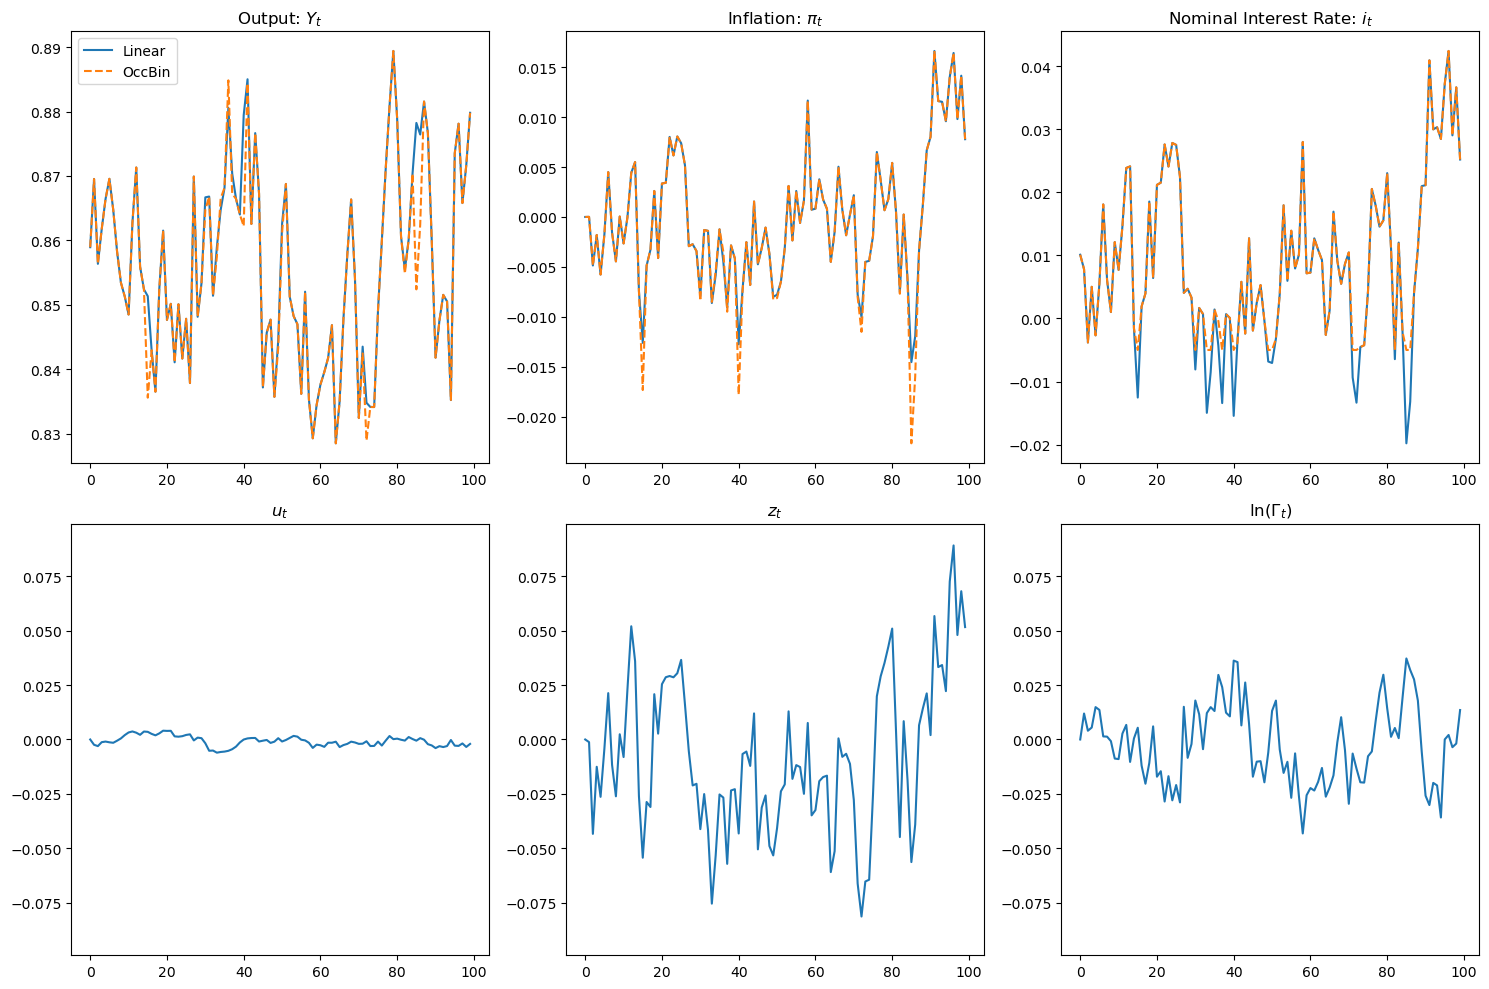

In [7]:
linear.simulate_linear(model, sigma_quad, 100, plot=True, key_=10)

# Check OccBin and log-linear with Dynare

Consider massive shocks of 10 standard-deviations to ensure solution holds even for extreme events

In [10]:
sigma_IRFs = {
    "sigma_eps_u": 0.0135,
    "sigma_eps_z": -0.20814, # make z-shock negative since it sends the economy to ZLB most often
    "sigma_eps_Gamma": 0.12778
}

Loading MatLab Results with:
{'sigma_eps_u': 0.0135, 'sigma_eps_z': -0.20814, 'sigma_eps_Gamma': 0.12778}


{'__header__': b'MATLAB 5.0 MAT-file, Platform: MACA64, Created on: Thu May 28 05:22:00 2026', '__version__': '1.0', '__globals__': [], 'all_linear_results': array([[[-8.54584549e-03,  8.54584549e-03,  3.65083259e-02,
         -3.65083259e-02,  9.89819160e-02, -9.89819160e-02],
        [-1.19087000e-02,  1.19087000e-02,  3.31080877e-02,
         -3.31080877e-02, -2.08337905e-02,  2.08337905e-02],
        [-8.63597269e-03,  8.63597269e-03,  6.79162945e-02,
         -6.79162945e-02, -4.56497278e-02,  4.56497278e-02],
        [-8.63597269e-03,  8.63597269e-03,  6.79162945e-02,
         -6.79162945e-02, -4.56497278e-02,  4.56497278e-02],
        [ 1.35000000e-02, -1.35000000e-02, -5.11514898e-18,
          5.11514898e-18, -1.91818087e-18,  1.91818087e-18],
        [ 0.00000000e+00,  0.00000000e+00,  2.08140000e-01,
         -2.08140000e-01,  0.00000000e+00,  0.00000000e+00],
        

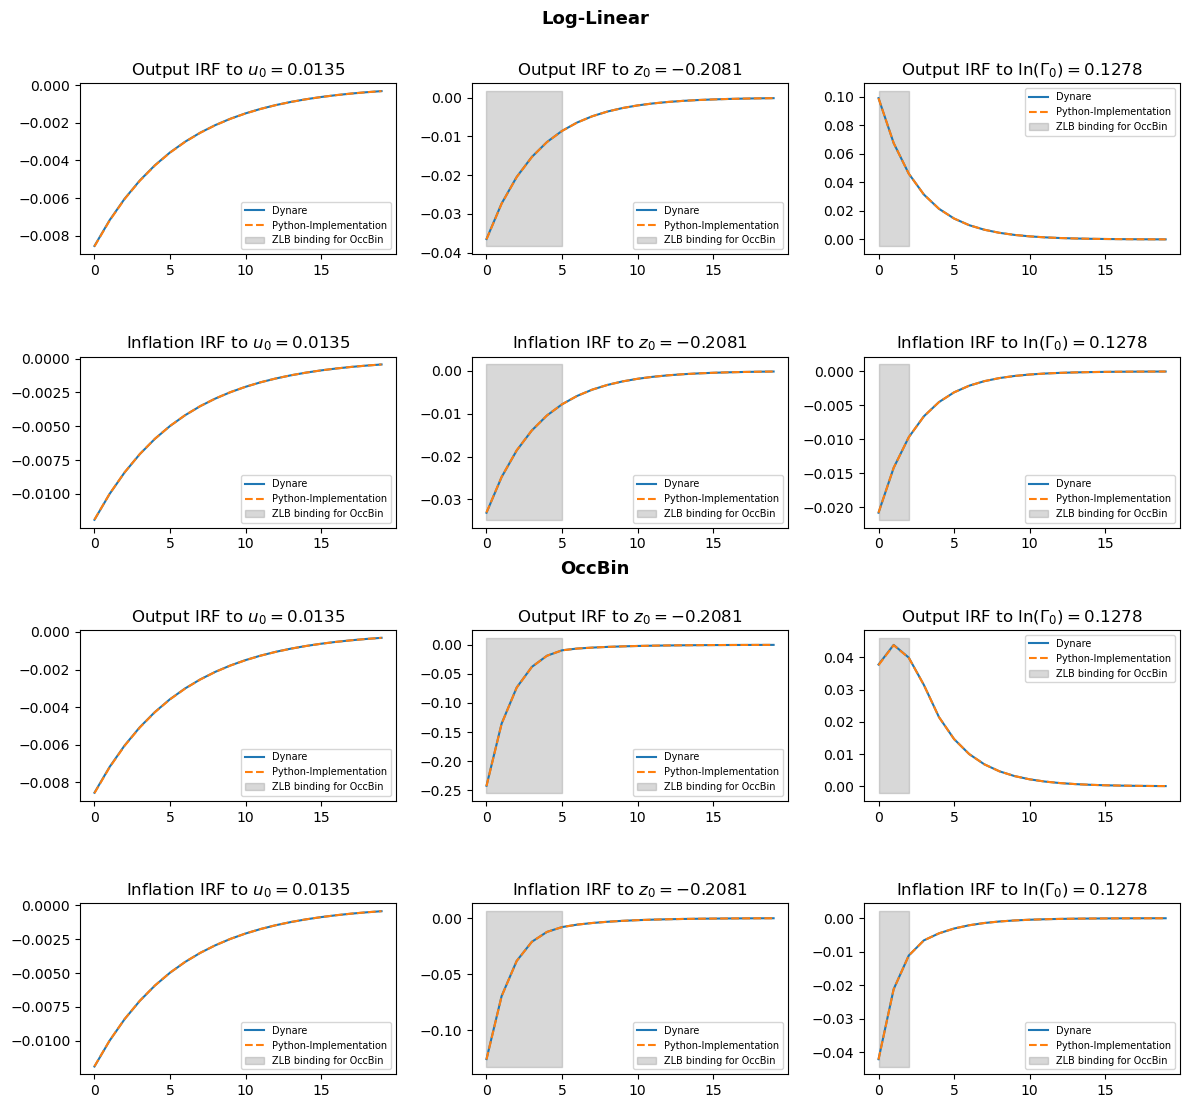

In [11]:
linear.check_dynare(model, "MatLab/all_6_shocks_results.mat", sigma_IRFs)